In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from tensorflow.keras import layers

In [3]:
rgb_image = np.zeros((100, 1000, 3))
rgb_image[25:75, 25:75, 0] = 1
rgb_image[40:60, 40:60, 1] = 1

In [4]:
edge_filter = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

red_edges = ndimage.convolve(rgb_image[:, :, 0], edge_filter)
green_edges = ndimage.convolve(rgb_image[:, :, 1], edge_filter)
blue_edges = ndimage.convolve(rgb_image[:, :, 2], edge_filter)

combine_edges = np.stack([red_edges, green_edges, blue_edges], axis=2)

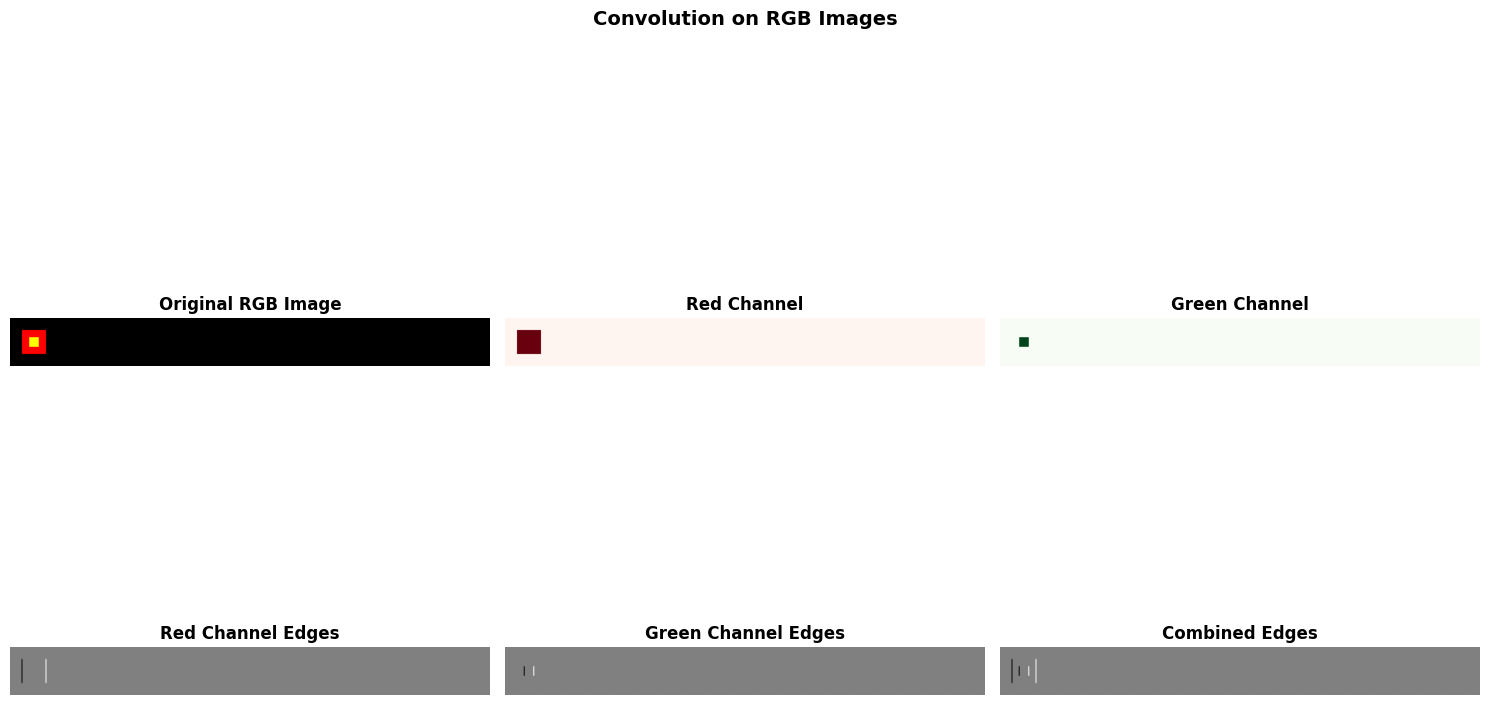

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(rgb_image)
axes[0, 0].set_title('Original RGB Image', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(rgb_image[:, :, 0], cmap='Reds')
axes[0, 1].set_title('Red Channel', fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(rgb_image[:, :, 1], cmap='Greens')
axes[0, 2].set_title('Green Channel', fontweight='bold')
axes[0, 2].axis('off')

axes[1, 0].imshow(red_edges, cmap='gray')
axes[1, 0].set_title('Red Channel Edges', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(green_edges, cmap='gray')
axes[1, 1].set_title('Green Channel Edges', fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(np.mean(combine_edges, axis=2), cmap='gray')
axes[1, 2].set_title('Combined Edges', fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle('Convolution on RGB Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**RGB Image Processing**

In [6]:
model = layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    input_shape=(224, 224, 3),
    padding='same'
)

model.build((None, 224, 224, 3))

print(f"Filter shape: {model.kernel.shape}") 

Filter shape: (3, 3, 3, 32)


C:\Users\User\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Multi-Channel Convolution**

In [7]:
def rgb_convolution_explanation():
    input_rgb = np.random.rand(5, 5, 3)
    filter_3d = np.random.rand(3, 3, 3)
    
    output = np.zeros((3, 3))
    
    for i in range(3):
        for j in range(3):
            region = input_rgb[i:i+3, j:j+3, :]
            output[i, j] = np.sum(region * filter_3d)
    
    return output

rgb_convolution_explanation()

array([[4.78206819, 4.60791535, 5.38924266],
       [5.13788716, 5.12580254, 5.4122835 ],
       [5.49172827, 5.18406413, 6.01044202]])